# Paradigm 1: Portfolio Construction via Informed Selection + Optimization

## Objective

We compare **three models** for S&P 500 index replication through a two-stage approach:

**Stage 1: Informed Selection** - Select K=50 assets using different methods
- **Model 1**: Stratified Sampling (structured approach)
- **Model 2**: Clustering (data-driven approach)
- **Model 3**: Correlation Ranking (naive baseline)

**Stage 2: Weight Optimization** - Optimize weights to minimize tracking error

$$\min_w \|I - R_S w\|_2^2$$

Subject to:
- $\sum w_i = 1$ (fully invested)
- $l_i \leq w_i \leq u_i$ (weight bounds)

## Test Setup
- **Universe**: ~500 S&P 500 constituents from sp500_tickers.csv
- **Period**: 2020-2023  
- **Selected Assets**: K=50 from N constituents
- **Index Returns**: Market-cap weighted returns of all constituents
- **Benchmark**: Buy-and-hold market-cap weighted portfolio

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from pathlib import Path
import warnings
import importlib
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

# Import custom modules from project
import sys
sys.path.append('.')

# Import and reload modules to get latest changes
import data
import models
import optimization
import backtest
import backtest_wang
import config

# Reload modules to get any recent changes
importlib.reload(data)
importlib.reload(models)
importlib.reload(optimization)
importlib.reload(backtest)
importlib.reload(backtest_wang)
importlib.reload(config)

from data import DataHandler
from models import StratifiedSamplingModel, ClusteringModel, CorrelationRankingModel
from optimization import PortfolioOptimizer
from backtest import BacktestEngine, StrategyComparator
from backtest_wang import WangBacktestEngine, WangComparator
from config import DATA_PARAMS, PORTFOLIO_PARAMS, OPTIMIZATION_PARAMS

print("✓ All libraries and custom modules imported successfully")

✓ All libraries and custom modules imported successfully


## Section 1: Data Fetching and Preparation

Fetch S&P 500 index and constituent data, compute returns and correlations.

In [2]:
# Initialize data handler
data_handler = DataHandler(
    index_ticker="^GSPC",
    start_date="2020-01-01",
    end_date="2023-12-31",
    data_dir="./data"
)

# Try to load cached data first
print("Checking for cached data...")
print("=" * 60)

if data_handler.load_data(prefix="sp500"):
    print("Using cached S&P 500 data")
else:
    print("No cached data found. Fetching fresh data...")
    print("=" * 60)
    
    # Fetch index data
    index_data = data_handler.fetch_index_data()
    print(f"✓ Index data fetched: {len(index_data)} trading days")
    
    # Fetch S&P 500 constituents (from CSV file)
    constituents = data_handler.fetch_sp500_constituents()
    print(f"✓ Found {len(constituents)} S&P 500 constituents")
    
    # Fetch constituent data
    constituents_data = data_handler.fetch_constituents_data(constituents)
    
    if constituents_data is not None:
        print(f"✓ Successfully fetched data for {len(constituents_data.columns)} assets with complete data")
    else:
        print("✗ Error: Could not fetch constituent data")
        raise ValueError("Failed to fetch constituent data")
    
    # Compute returns (using market-cap weighted index)
    returns, index_returns = data_handler.compute_returns(use_market_cap_weights=True)
    print(f"✓ Computed returns for {len(returns.columns)} assets")
    print(f"✓ Index returns computed using market-cap weighting")
    
    # Compute correlations
    correlation_matrix = data_handler.compute_correlation_matrix()
    print(f"✓ Computed correlations with index")
    
    # Save data to files
    print("\nSaving data to cache...")
    data_handler.save_data(prefix="sp500")

print("\n" + "=" * 60)
print(f"Data Summary:")
print(f"  Date Range: {data_handler.returns.index[0].date()} to {data_handler.returns.index[-1].date()}")
print(f"  Number of Assets: {len(data_handler.returns.columns)}")
print(f"  Number of Trading Days: {len(data_handler.returns)}")
print(f"  Top 5 Correlated Assets:")
print(data_handler.correlation_matrix.head(5))

# Convenience variables for ease of use
returns = data_handler.returns
index_returns = data_handler.index_returns
correlation_matrix = data_handler.correlation_matrix

Checking for cached data...
✗ Error loading data: read_csv() got an unexpected keyword argument 'squeeze'
No cached data found. Fetching fresh data...
Fetching ^GSPC data...
✓ Index data fetched: 1006 trading days
Fetching S&P 500 constituents...
✓ Successfully loaded 503 tickers from data\sp500_tickers.csv
✓ Found 503 S&P 500 constituents
Fetching data for 503 constituents...


$BRK.B: possibly delisted; no timezone found
$BF.B: possibly delisted; no price data found  (1d 2020-01-01 -> 2023-12-31)

2 Failed downloads:
['BRK.B']: possibly delisted; no timezone found
['BF.B']: possibly delisted; no price data found  (1d 2020-01-01 -> 2023-12-31)


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: FI"}}}
$FI: possibly delisted; no timezone found

1 Failed download:
['FI']: possibly delisted; no timezone found


$GEV: possibly delisted; no price data found  (1d 2020-01-01 -> 2023-12-31) (Yahoo error = "Data doesn't exist for startDate = 1577854800, endDate = 1703998800")

1 Failed download:
['GEV']: possibly delisted; no price data found  (1d 2020-01-01 -> 2023-12-31) (Yahoo error = "Data doesn't exist for startDate = 1577854800, endDate = 1703998800")


$K: possibly delisted; no timezone found
$IPG: possibly delisted; no timezone found

2 Failed downloads:
['K', 'IPG']: possibly delisted; no timezone found


$SOLV: possibly delisted; no price data found  (1d 2020-01-01 -> 2023-12-31) (Yahoo error = "Data doesn't exist for startDate = 1577854800, endDate = 1703998800")

1 Failed download:
['SOLV']: possibly delisted; no price data found  (1d 2020-01-01 -> 2023-12-31) (Yahoo error = "Data doesn't exist for startDate = 1577854800, endDate = 1703998800")


$WBA: possibly delisted; no timezone found

1 Failed download:
['WBA']: possibly delisted; no timezone found


Successfully fetched data for 200 assets
✓ Successfully fetched data for 200 assets with complete data

Computing market-cap weighted index returns...
Fetching market caps for 200 tickers...
  Batch 1/4...
  Batch 2/4...
  Batch 3/4...
  Batch 4/4...
✓ Successfully fetched market caps for 200 tickers
✓ Computed market-cap weighted returns using 200 assets
   Largest weights: {'NVDA': 0.11542708397750454, 'AAPL': 0.10286982939988844, 'GOOGL': 0.0953459291288588, 'GOOG': 0.09527458342121782, 'MSFT': 0.07655967803616438}
✓ Computed returns for 200 assets
✓ Index returns computed using market-cap weighting
✓ Computed correlations with index

Saving data to cache...
✓ Saved constituent prices to data\sp500_prices.csv
✓ Saved index prices to data\sp500_index.csv
✓ Saved constituent returns to data\sp500_returns.csv
✓ Saved index returns to data\sp500_index_returns.csv
✓ Saved correlations to data\sp500_correlations.csv
✓ Saved constituents list to data\sp500_constituents.txt

Data Summary:
 

## Section 1.5: Data Export and Verification

Export comprehensive S&P 500 data for analysis and verification.

In [3]:
# COMPREHENSIVE DATA EXPORT AND VERIFICATION
from pathlib import Path

print("=" * 80)
print("COMPREHENSIVE S&P 500 DATA EXPORT AND VERIFICATION")
print("=" * 80)

# Create exports directory
export_dir = Path("./data/exports")
export_dir.mkdir(exist_ok=True, parents=True)

# 1. Export constituent list with sectors
print("\n1. Exporting constituent list with sectors...")
sector_mapping = data_handler.get_sector_mapping()
constituents_info = pd.DataFrame({
    'Ticker': data_handler.constituents_list,
    'In_Dataset': [t in returns.columns for t in data_handler.constituents_list],
    'Sector': [sector_mapping.get(t, 'Unknown') for t in data_handler.constituents_list]
})
constituents_info.to_csv(export_dir / 'sp500_constituents_info.csv', index=False)
print(f"   ✓ Saved {len(constituents_info)} constituents")
print(f"   With complete data: {constituents_info['In_Dataset'].sum()}")

# 2. Export prices
data_handler.constituents_data.to_csv(export_dir / 'sp500_prices_full.csv')
print(f"\n2. ✓ Exported price data: {len(data_handler.constituents_data.columns)} assets x {len(data_handler.constituents_data)} days")

# 3. Export returns
returns.to_csv(export_dir / 'sp500_returns_full.csv')
print(f"3. ✓ Exported returns data")

# 4. Export correlations with sector info
corr_with_sectors = pd.DataFrame({
    'Ticker': correlation_matrix.index,
    'Correlation': correlation_matrix.values,
    'Sector': [sector_mapping.get(t, 'Unknown') for t in correlation_matrix.index]
}).sort_values('Correlation', ascending=False)
corr_with_sectors.to_csv(export_dir / 'sp500_correlations_with_sectors.csv', index=False)
print(f"4. ✓ Exported correlations with sectors")

# 5. Sector statistics
sector_stats = corr_with_sectors.groupby('Sector').agg({
    'Ticker': 'count',
    'Correlation': ['mean', 'min', 'max']
}).round(4)
sector_stats.columns = ['Num_Assets', 'Avg_Correlation', 'Min_Correlation', 'Max_Correlation']
sector_stats = sector_stats.sort_values('Num_Assets', ascending=False)
sector_stats.to_csv(export_dir / 'sp500_sector_statistics.csv')
print(f"5. ✓ Exported sector statistics ({len(sector_stats)} sectors)")

# 6. Export index data (align prices with returns - returns start from day 2)
index_df = pd.DataFrame({
    'Date': data_handler.index_returns.index,
    'Price': data_handler.index_data.loc[data_handler.index_returns.index].values,
    'Return': data_handler.index_returns.values
})
index_df.to_csv(export_dir / 'sp500_index_data.csv', index=False)
print(f"6. ✓ Exported index data")

# Summary
print("\n" + "=" * 80)
print("DATA VERIFICATION SUMMARY")
print("=" * 80)
print(f"📊 Dataset: {len(returns.columns)} assets with complete data")
print(f"📅 Period: {returns.index[0].date()} to {returns.index[-1].date()} ({len(returns)} days)")
print(f"🏢 Sectors: {len(sector_stats)} unique sectors")
print(f"🔗 Correlation: [{correlation_matrix.min():.4f}, {correlation_matrix.max():.4f}]")
print(f"\n💾 All files saved to: {export_dir.absolute()}")
print("=" * 80)

COMPREHENSIVE S&P 500 DATA EXPORT AND VERIFICATION

1. Exporting constituent list with sectors...
   ✓ Saved 503 constituents
   With complete data: 200

2. ✓ Exported price data: 200 assets x 818 days
3. ✓ Exported returns data
4. ✓ Exported correlations with sectors
5. ✓ Exported sector statistics (11 sectors)
6. ✓ Exported index data

DATA VERIFICATION SUMMARY
📊 Dataset: 200 assets with complete data
📅 Period: 2020-10-01 to 2023-12-29 (817 days)
🏢 Sectors: 11 unique sectors
🔗 Correlation: [0.1142, 0.8589]

💾 All files saved to: c:\Users\aicha\Downloads\these master\Structured-vs-Endogenous-Portfolio-Construction-for-Partial-Index-Replication\data\exports


## Section 2: Asset Selection Using Three Models

Compare three different methods to select K=50 assets from the available constituents.

In [4]:
# Model 1: Stratified Sampling
print("\n" + "=" * 60)
print("MODEL 1: STRATIFIED SAMPLING (Baseline)")
print("=" * 60)

model1_stratified = StratifiedSamplingModel(K=PORTFOLIO_PARAMS["K"], num_strata=PORTFOLIO_PARAMS["num_strata"])
sector_mapping = data_handler.get_sector_mapping()

selected_assets_1 = model1_stratified.select(
    returns=returns,
    correlation_matrix=correlation_matrix,
    sector_mapping=sector_mapping
)

print(f"✓ Selected {len(selected_assets_1)} assets using stratified sampling")
print(f"\nSelected assets:\n{selected_assets_1}")
print(f"\nCorrelations of selected assets:")
print(correlation_matrix[correlation_matrix.index.isin(selected_assets_1)].head(10))


MODEL 1: STRATIFIED SAMPLING (Baseline)
Stratified Sampling: Selecting from 11 sectors
  Industrials: 7/7 assets
  Health Care: 7/7 assets
  Information Technology: 8/8 assets
  Utilities: 4/4 assets
  Financials: 8/8 assets
  Materials: 2/2 assets
  Real Estate: 2/2 assets
  Communication Services: 2/2 assets
  Consumer Staples: 5/5 assets
  Consumer Discretionary: 3/3 assets
  Energy: 2/2 assets
Total selected: 50 assets
✓ Selected 50 assets using stratified sampling

Selected assets:
['CPRT', 'DAY', 'CTAS', 'PAYX', 'AME', 'ODFL', 'NDSN', 'MTD', 'ZTS', 'A', 'COO', 'ALGN', 'DHR', 'DXCM', 'MSFT', 'NVDA', 'AAPL', 'ADBE', 'AMD', 'APH', 'MCHP', 'ADI', 'AES', 'AWK', 'NEE', 'NRG', 'MSCI', 'MCO', 'MA', 'AMP', 'APO', 'PYPL', 'MMC', 'NDAQ', 'MLM', 'PPG', 'CSGP', 'PLD', 'GOOGL', 'GOOG', 'COST', 'MNST', 'PEP', 'MDLZ', 'STZ', 'AMZN', 'CMG', 'APTV', 'OKE', 'APA']

Correlations of selected assets:
Ticker
GOOGL    0.858898
GOOG     0.857835
MSFT     0.851252
NVDA     0.837926
AAPL     0.822397
AMZN

In [5]:
# Model 2: Clustering
print("\n" + "=" * 60)
print("MODEL 2: CLUSTERING (Data-Driven)")
print("=" * 60)

model2_clustering = ClusteringModel(K=PORTFOLIO_PARAMS["K"], num_clusters=PORTFOLIO_PARAMS["num_clusters"])
selected_assets_2 = model2_clustering.select(
    returns=returns,
    correlation_matrix=correlation_matrix
)

print(f"✓ Selected {len(selected_assets_2)} assets using clustering method")
print(f"\nSelected assets:\n{selected_assets_2}")
print(f"\nCorrelations of selected assets:")
print(correlation_matrix[correlation_matrix.index.isin(selected_assets_2)].head(10))


MODEL 2: CLUSTERING (Data-Driven)
Clustering: Performing K-means with 10 clusters on return features
  Cluster 0: 10 assets → selected 2
  Cluster 1: 62 assets → selected 15
  Cluster 2: 66 assets → selected 16
  Cluster 3: 1 assets → selected 1
  Cluster 4: 16 assets → selected 4
  Cluster 5: 1 assets → selected 1
  Cluster 6: 1 assets → selected 1
  Cluster 7: 8 assets → selected 2
  Cluster 8: 1 assets → selected 1
  Cluster 9: 34 assets → selected 8
  Reduced to K=50 by keeping most correlated
Total selected: 50 assets
✓ Selected 50 assets using clustering method

Selected assets:
['GOOGL', 'GOOG', 'MSFT', 'NVDA', 'AAPL', 'AMZN', 'ADBE', 'AMD', 'APH', 'ACN', 'CPRT', 'ADSK', 'MSCI', 'META', 'MCO', 'CTAS', 'MA', 'ZBRA', 'AMP', 'PAYX', 'MTD', 'APO', 'AME', 'APTV', 'COST', 'MMC', 'PH', 'CPAY', 'MGM', 'MS', 'AJG', 'AXP', 'DXCM', 'PLTR', 'ABT', 'AON', 'NCLH', 'DLR', 'AMT', 'MAA', 'MCD', 'CCI', 'AWK', 'PEP', 'MDLZ', 'MDT', 'STZ', 'PSA', 'MRNA', 'APA']

Correlations of selected assets:
Ti

In [6]:
# Model 3: Correlation Ranking
print("\n" + "=" * 60)
print("MODEL 3: CORRELATION RANKING (Naive Baseline)")
print("=" * 60)

model3_correlation = CorrelationRankingModel(K=PORTFOLIO_PARAMS["K"])
selected_assets_3 = model3_correlation.select(
    returns=returns,
    correlation_matrix=correlation_matrix
)

print(f"✓ Selected {len(selected_assets_3)} assets using correlation ranking")
print(f"\nSelected assets:\n{selected_assets_3}")
print(f"\nCorrelations of selected assets:")
print(correlation_matrix[correlation_matrix.index.isin(selected_assets_3)].head(10))

# Summary of selections
print("\n" + "=" * 60)
print("SELECTION SUMMARY")
print("=" * 60)
print(f"Model 1 (Stratified):  {len(selected_assets_1)} assets, avg correlation: {correlation_matrix[correlation_matrix.index.isin(selected_assets_1)].mean():.4f}")
print(f"Model 2 (Clustering):  {len(selected_assets_2)} assets, avg correlation: {correlation_matrix[correlation_matrix.index.isin(selected_assets_2)].mean():.4f}")
print(f"Model 3 (Correlation): {len(selected_assets_3)} assets, avg correlation: {correlation_matrix[correlation_matrix.index.isin(selected_assets_3)].mean():.4f}")
print(f"\nOverlap between models:")
overlap_12 = len(set(selected_assets_1) & set(selected_assets_2))
overlap_13 = len(set(selected_assets_1) & set(selected_assets_3))
overlap_23 = len(set(selected_assets_2) & set(selected_assets_3))
print(f"  Model 1 ∩ Model 2: {overlap_12} assets")
print(f"  Model 1 ∩ Model 3: {overlap_13} assets")
print(f"  Model 2 ∩ Model 3: {overlap_23} assets")


MODEL 3: CORRELATION RANKING (Naive Baseline)
Correlation Ranking: Selecting top 50 assets by correlation with index
  Selected asset correlations: min=0.5751, max=0.8589, mean=0.6761
✓ Selected 50 assets using correlation ranking

Selected assets:
['GOOGL', 'GOOG', 'MSFT', 'NVDA', 'AAPL', 'AMZN', 'ADBE', 'AMD', 'APH', 'MCHP', 'ADI', 'AMAT', 'ACN', 'MPWR', 'CPRT', 'QCOM', 'NXPI', 'ADSK', 'MSCI', 'META', 'MCO', 'ON', 'DAY', 'MU', 'CTAS', 'CMG', 'MA', 'ZBRA', 'AMP', 'PAYX', 'MTD', 'PTC', 'APO', 'AME', 'PYPL', 'APTV', 'ANET', 'COST', 'CTSH', 'DDOG', 'MMC', 'ZTS', 'A', 'NKE', 'ODFL', 'NDSN', 'MSI', 'PNR', 'NDAQ', 'MTCH']

Correlations of selected assets:
Ticker
GOOGL    0.858898
GOOG     0.857835
MSFT     0.851252
NVDA     0.837926
AAPL     0.822397
AMZN     0.780685
ADBE     0.758477
AMD      0.757364
APH      0.754198
MCHP     0.754122
dtype: float64

SELECTION SUMMARY
Model 1 (Stratified):  50 assets, avg correlation: 0.6106
Model 2 (Clustering):  50 assets, avg correlation: 0.5904
Mod

## Section 3: Weight Optimization

Optimize portfolio weights for each model to minimize tracking error: $\min_w \|I - R_S w\|_2^2$

In [7]:
# Optimize weights for all three models
print("\n" + "=" * 60)
print("WEIGHT OPTIMIZATION")
print("=" * 60)

# Model 1: Stratified Sampling
print("\nOptimizing weights for Model 1 (Stratified Sampling)...")
optimizer1 = PortfolioOptimizer(
    lower_bound=OPTIMIZATION_PARAMS["lower_bound"],
    upper_bound=OPTIMIZATION_PARAMS["upper_bound"]
)
selected_returns_1 = returns[selected_assets_1]
weights_1 = optimizer1.optimize(selected_returns_1, index_returns)
print("✓ Optimization complete")
print(f"  Objective function value: {optimizer1.optimization_result.fun:.6f}")
print(f"  Max weight: {weights_1.max():.4f}")
print(f"  Min weight: {weights_1.min():.4f}")
print(f"  Non-zero weights: {(weights_1 > 1e-6).sum()}/{len(weights_1)}")

# Model 2: Clustering
print("\nOptimizing weights for Model 2 (Clustering)...")
optimizer2 = PortfolioOptimizer()
selected_returns_2 = returns[selected_assets_2]
weights_2 = optimizer2.optimize(selected_returns_2, index_returns)
print("✓ Optimization complete")
print(f"  Objective function value: {optimizer2.optimization_result.fun:.6f}")
print(f"  Max weight: {weights_2.max():.4f}")
print(f"  Min weight: {weights_2.min():.4f}")
print(f"  Non-zero weights: {(weights_2 > 1e-6).sum()}/{len(weights_2)}")

# Model 3: Correlation Ranking
print("\nOptimizing weights for Model 3 (Correlation Ranking)...")
optimizer3 = PortfolioOptimizer()
selected_returns_3 = returns[selected_assets_3]
weights_3 = optimizer3.optimize(selected_returns_3, index_returns)
print("✓ Optimization complete")
print(f"  Objective function value: {optimizer3.optimization_result.fun:.6f}")
print(f"  Max weight: {weights_3.max():.4f}")
print(f"  Min weight: {weights_3.min():.4f}")
print(f"  Non-zero weights: {(weights_3 > 1e-6).sum()}/{len(weights_3)}")

print("\n" + "=" * 60)


WEIGHT OPTIMIZATION

Optimizing weights for Model 1 (Stratified Sampling)...
✓ Optimization complete
  Objective function value: 0.001492
  Max weight: 0.1000
  Min weight: 0.0000
  Non-zero weights: 42/50

Optimizing weights for Model 2 (Clustering)...
✓ Optimization complete
  Objective function value: 0.000737
  Max weight: 0.1000
  Min weight: 0.0000
  Non-zero weights: 45/50

Optimizing weights for Model 3 (Correlation Ranking)...
✓ Optimization complete
  Objective function value: 0.001547
  Max weight: 0.1000
  Min weight: 0.0000
  Non-zero weights: 33/50



## Section 4: Backtesting and Performance Analysis

Test all three strategies on the full dataset and compare performance metrics.

In [8]:
# Initialize backtesting engine
backtest_engine = BacktestEngine(
    index_prices=data_handler.index_data,
    constituents_prices=data_handler.constituents_data,
    index_returns=data_handler.index_returns,
    constituents_returns=data_handler.returns,
    slippage=0.001
)

# Run backtests
print("\n" + "=" * 60)
print("BACKTESTING RESULTS")
print("=" * 60)

print("\nModel 1: Stratified Sampling")
result1 = backtest_engine.backtest(
    selected_assets=selected_assets_1,
    weights=weights_1
)

print("\nModel 2: Clustering")
result2 = backtest_engine.backtest(
    selected_assets=selected_assets_2,
    weights=weights_2
)

print("\nModel 3: Correlation Ranking")
result3 = backtest_engine.backtest(
    selected_assets=selected_assets_3,
    weights=weights_3
)

print("\nBenchmark: Market-Cap Weighted Index (Buy-and-Hold)")
result_sp500 = backtest_engine.backtest_index()

# Collect results
comparator = StrategyComparator()
comparator.add_result("Stratified Sampling", result1)
comparator.add_result("Clustering", result2)
comparator.add_result("Correlation Ranking", result3)
comparator.add_result("Market-Cap Weighted Index", result_sp500)

print("\n" + "=" * 60)
print("PERFORMANCE COMPARISON")
print("=" * 60)
comparison_df = comparator.get_comparison_df()
print(comparison_df.to_string())

# Save results
results_summary = comparison_df.copy()
results_summary


BACKTESTING RESULTS

Model 1: Stratified Sampling

Model 2: Clustering

Model 3: Correlation Ranking

Benchmark: Market-Cap Weighted Index (Buy-and-Hold)

PERFORMANCE COMPARISON
                           Portfolio Return (%)  Index Return (%)  Excess Return (%)  Tracking Error (%)  Mean Tracking Error (%)  Sharpe Ratio  Max Drawdown (%)  Num Assets
Stratified Sampling                   60.228598         62.574989          -2.346390            0.021451                -0.354954      0.733069        -36.628718        50.0
Clustering                            61.172358         62.574989          -1.402631            0.015075                -0.180913      0.741370        -38.407896        50.0
Correlation Ranking                   63.619453         62.574989           1.044464            0.021842                 0.416830      0.749076        -38.760379        50.0
Market-Cap Weighted Index             62.574989         62.574989           0.000000            0.000000                 0.00

,Portfolio Return (%),Index Return (%),Excess Return (%),Tracking Error (%),Mean Tracking Error (%),Sharpe Ratio,Max Drawdown (%),Num Assets
Stratified Sampling,60.228598,62.574989,-2.346390,0.021451,-0.354954,0.733069,-36.628718,50.0
Clustering,61.172358,62.574989,-1.402631,0.015075,-0.180913,0.741370,-38.407896,50.0
Correlation Ranking,63.619453,62.574989,1.044464,0.021842,0.416830,0.749076,-38.760379,50.0
Market-Cap Weighted Index,62.574989,62.574989,0.000000,0.000000,0.000000,0.756535,-38.127441,200.0


## Section 4.5: Wang et al. (2018) Compliant Evaluation

**Proper academic evaluation following Wang et al. methodology:**

This section implements the **correct** evaluation framework for Paradigm 1 (Selection + Optimization):

### Key Differences from Previous Section:
1. **Train/Test Split**: Data split into 70% in-sample (training) and 30% out-of-sample (testing)
2. **Training on In-Sample Only**: Asset selection and weight optimization performed only on training data
3. **Testing on Both Periods**: Evaluate performance on both in-sample and out-of-sample
4. **Wang et al. Metrics**:
   - **TE**: Tracking Error = sqrt((1/T) * ||I - R*w||²) 
   - **Std_TE**: Robustness measure (std of squared tracking errors)
   - **Mean_Corr**: Mean correlation of selected assets with index
   - **Consistency**: |TE_in - TE_out| (measures overfitting)

### Expected Behavior (from Wang et al.):
- **S-Strategy** (Stratified): Moderate TE, good consistency, high correlation
- **Clustering**: Data-driven selection, potentially lower TE but risk of overfitting  
- **Correlation Ranking**: Simple baseline, highest correlation but may overfit

In [9]:
# WANG ET AL. (2018) COMPLIANT EVALUATION
# Import the proper evaluation framework
import importlib
import backtest_wang
importlib.reload(backtest_wang)
from backtest_wang import WangBacktestEngine, WangComparator

print("=" * 80)
print("PARADIGM 1 EVALUATION - WANG ET AL. (2018) METHODOLOGY")
print("=" * 80)
print("\n📚 Paper: 'Structured vs Endogenous Portfolio Construction'")
print("   This evaluation follows the exact methodology from the paper\n")

# Initialize Wang backtest engine
wang_engine = WangBacktestEngine(
    returns=returns,
    index_returns=index_returns,
    correlation_matrix=correlation_matrix,
    train_ratio=0.7,  # 70% training, 30% testing
    slippage=0.001
)

# Initialize comparator
wang_comparator = WangComparator()

# Get K from config
K = PORTFOLIO_PARAMS["K"]

print(f"\n🎯 Portfolio Size: K = {K}")
print(f"📊 Universe Size: N = {len(returns.columns)}")
print(f"📅 Full Period: {returns.index[0].date()} to {returns.index[-1].date()}")

PARADIGM 1 EVALUATION - WANG ET AL. (2018) METHODOLOGY

📚 Paper: 'Structured vs Endogenous Portfolio Construction'
   This evaluation follows the exact methodology from the paper

Data split:
  In-sample:     2020-10-01 to 2023-01-06 (571 days)
  Out-of-sample: 2023-01-09 to 2023-12-29 (246 days)

🎯 Portfolio Size: K = 50
📊 Universe Size: N = 200
📅 Full Period: 2020-10-01 to 2023-12-29


In [10]:
# MODEL 1: STRATIFIED SAMPLING (S-STRATEGY from Wang et al.)
from models import StratifiedSamplingModel
from optimization import PortfolioOptimizer

model1_wang = StratifiedSamplingModel(K=K, num_strata=10)
opt1_wang = PortfolioOptimizer()

result1_wang = wang_engine.backtest_strategy(
    selection_model=model1_wang,
    optimizer=opt1_wang,
    strategy_name="S-Strategy (Stratified Sampling)",
    sector_mapping=sector_mapping
)

wang_comparator.add_result(result1_wang)


BACKTESTING: S-Strategy (Stratified Sampling)

[IN-SAMPLE PHASE]
1. Selecting assets...
Stratified Sampling: Selecting from 11 sectors
  Industrials: 7/7 assets
  Health Care: 7/7 assets
  Information Technology: 8/8 assets
  Utilities: 4/4 assets
  Financials: 8/8 assets
  Materials: 2/2 assets
  Real Estate: 2/2 assets
  Communication Services: 2/2 assets
  Consumer Staples: 5/5 assets
  Consumer Discretionary: 3/3 assets
  Energy: 2/2 assets
Total selected: 50 assets
   ✓ Selected 50 assets
2. Optimizing weights...
   ✓ Weights optimized (objective: 0.001085)
3. Computing in-sample metrics...


   ✓ IN-SAMPLE: TE=0.1378%, Std_TE=0.0006, Mean_Corr=0.6524, Return=7.99%

[OUT-OF-SAMPLE PHASE]
4. Computing out-of-sample metrics...
   ✓ OUT-OF-SAMPLE: TE=0.1388%, Std_TE=0.0003, Mean_Corr=0.4576, Return=48.28%

[FULL PERIOD]
5. Computing full period metrics...
   ✓ FULL: TE=0.1381%, Std_TE=0.0005, Mean_Corr=0.6083, Return=60.13%

WANG ET AL. EVALUATION SUMMARY: S-Strategy (Stratified Sampling)

📊 ASSET SELECTION
   Number of assets: 50
   Mean correlation: 0.6524 (in-sample), 0.4576 (out-of-sample)

📈 IN-SAMPLE PERFORMANCE
   TE_in:      0.1378%
   Std_TE_in:  0.0006
   Return_in:  7.99%
   Sharpe_in:  0.2608

📉 OUT-OF-SAMPLE PERFORMANCE
   TE_out:     0.1388%
   Std_TE_out: 0.0003
   Return_out: 48.28%
   Sharpe_out: 2.3513

🎯 CONSISTENCY
   |TE_in - TE_out|: 0.0009%

📅 PERIOD INFORMATION
   In-sample:     2020-10-01 to 2023-01-06 (571 days)
   Out-of-sample: 2023-01-09 to 2023-12-29 (246 days)



In [11]:
# MODEL 2: CLUSTERING
from models import ClusteringModel

model2_wang = ClusteringModel(K=K, num_clusters=min(10, K))
opt2_wang = PortfolioOptimizer()

result2_wang = wang_engine.backtest_strategy(
    selection_model=model2_wang,
    optimizer=opt2_wang,
    strategy_name="Clustering (Data-Driven)"
)

wang_comparator.add_result(result2_wang)


BACKTESTING: Clustering (Data-Driven)

[IN-SAMPLE PHASE]
1. Selecting assets...
Clustering: Performing K-means with 10 clusters on return features
  Cluster 0: 11 assets → selected 2
  Cluster 1: 69 assets → selected 17
  Cluster 2: 33 assets → selected 8
  Cluster 3: 48 assets → selected 12
  Cluster 4: 1 assets → selected 1
  Cluster 5: 3 assets → selected 1
  Cluster 6: 10 assets → selected 2
  Cluster 7: 1 assets → selected 1
  Cluster 8: 6 assets → selected 1
  Cluster 9: 18 assets → selected 4
  Added 1 additional assets to reach K=50
Total selected: 50 assets
   ✓ Selected 50 assets
2. Optimizing weights...


   ✓ Weights optimized (objective: 0.001161)
3. Computing in-sample metrics...
   ✓ IN-SAMPLE: TE=0.1426%, Std_TE=0.0007, Mean_Corr=0.6229, Return=7.47%

[OUT-OF-SAMPLE PHASE]
4. Computing out-of-sample metrics...
   ✓ OUT-OF-SAMPLE: TE=0.1639%, Std_TE=0.0006, Mean_Corr=0.4451, Return=45.47%

[FULL PERIOD]
5. Computing full period metrics...
   ✓ FULL: TE=0.1493%, Std_TE=0.0007, Mean_Corr=0.5811, Return=56.34%

WANG ET AL. EVALUATION SUMMARY: Clustering (Data-Driven)

📊 ASSET SELECTION
   Number of assets: 50
   Mean correlation: 0.6229 (in-sample), 0.4451 (out-of-sample)

📈 IN-SAMPLE PERFORMANCE
   TE_in:      0.1426%
   Std_TE_in:  0.0007
   Return_in:  7.47%
   Sharpe_in:  0.2524

📉 OUT-OF-SAMPLE PERFORMANCE
   TE_out:     0.1639%
   Std_TE_out: 0.0006
   Return_out: 45.47%
   Sharpe_out: 2.2355

🎯 CONSISTENCY
   |TE_in - TE_out|: 0.0213%

📅 PERIOD INFORMATION
   In-sample:     2020-10-01 to 2023-01-06 (571 days)
   Out-of-sample: 2023-01-09 to 2023-12-29 (246 days)



In [12]:
# MODEL 3: CORRELATION RANKING (NAIVE BASELINE)
from models import CorrelationRankingModel

model3_wang = CorrelationRankingModel(K=K)
opt3_wang = PortfolioOptimizer()

result3_wang = wang_engine.backtest_strategy(
    selection_model=model3_wang,
    optimizer=opt3_wang,
    strategy_name="Correlation Ranking (Baseline)"
)

wang_comparator.add_result(result3_wang)


BACKTESTING: Correlation Ranking (Baseline)

[IN-SAMPLE PHASE]
1. Selecting assets...
Correlation Ranking: Selecting top 50 assets by correlation with index
  Selected asset correlations: min=0.6269, max=0.8842, mean=0.7176
   ✓ Selected 50 assets
2. Optimizing weights...
   ✓ Weights optimized (objective: 0.001095)
3. Computing in-sample metrics...


   ✓ IN-SAMPLE: TE=0.1385%, Std_TE=0.0003, Mean_Corr=0.7176, Return=6.18%

[OUT-OF-SAMPLE PHASE]
4. Computing out-of-sample metrics...
   ✓ OUT-OF-SAMPLE: TE=0.1409%, Std_TE=0.0003, Mean_Corr=0.5296, Return=54.10%

[FULL PERIOD]
5. Computing full period metrics...
   ✓ FULL: TE=0.1392%, Std_TE=0.0003, Mean_Corr=0.6753, Return=63.63%

WANG ET AL. EVALUATION SUMMARY: Correlation Ranking (Baseline)

📊 ASSET SELECTION
   Number of assets: 50
   Mean correlation: 0.7176 (in-sample), 0.5296 (out-of-sample)

📈 IN-SAMPLE PERFORMANCE
   TE_in:      0.1385%
   Std_TE_in:  0.0003
   Return_in:  6.18%
   Sharpe_in:  0.2323

📉 OUT-OF-SAMPLE PERFORMANCE
   TE_out:     0.1409%
   Std_TE_out: 0.0003
   Return_out: 54.10%
   Sharpe_out: 2.5012

🎯 CONSISTENCY
   |TE_in - TE_out|: 0.0025%

📅 PERIOD INFORMATION
   In-sample:     2020-10-01 to 2023-01-06 (571 days)
   Out-of-sample: 2023-01-09 to 2023-12-29 (246 days)



In [13]:
# COMPREHENSIVE COMPARISON TABLE
wang_comparator.print_comparison()

# Save to CSV for thesis
wang_comparator.save_to_csv("./data/exports/wang_evaluation_results.csv")

# Store for visualization
wang_comparison_df = wang_comparator.get_comparison_table()
wang_comparison_df


WANG ET AL. (2018) COMPARISON TABLE - PARADIGM 1: SELECTION + OPTIMIZATION
                                   K  Mean_Corr_in  TE_in (%)  Std_TE_in  Mean_Corr_out  TE_out (%)  Std_TE_out  Consistency  Return_in (%)  Return_out (%)  Sharpe_in  Sharpe_out
Strategy                                                                                                                                                                          
S-Strategy (Stratified Sampling)  50      0.652413   0.137846   0.000590       0.457559    0.138762    0.000350     0.000915       7.992271       48.278122   0.260760    2.351306
Clustering (Data-Driven)          50      0.622938   0.142584   0.000713       0.445072    0.163922    0.000560     0.021338       7.472054       45.470678   0.252420    2.235450
Correlation Ranking (Baseline)    50      0.717561   0.138465   0.000295       0.529630    0.140919    0.000337     0.002453       6.180325       54.101610   0.232264    2.501201

📝 INTERPRETATION GUIDE (from

,K,Mean_Corr_in,TE_in (%),Std_TE_in,Mean_Corr_out,TE_out (%),Std_TE_out,Consistency,Return_in (%),Return_out (%),Sharpe_in,Sharpe_out
Strategy,,,,,,,,,,,,
S-Strategy (Stratified Sampling),50,0.652413,0.137846,0.000590,0.457559,0.138762,0.000350,0.000915,7.992271,48.278122,0.260760,2.351306
Clustering (Data-Driven),50,0.622938,0.142584,0.000713,0.445072,0.163922,0.000560,0.021338,7.472054,45.470678,0.252420,2.235450
Correlation Ranking (Baseline),50,0.717561,0.138465,0.000295,0.529630,0.140919,0.000337,0.002453,6.180325,54.101610,0.232264,2.501201


In [14]:
# VERIFICATION: Check that Mean_Corr_in ≠ Mean_Corr_out (CRITICAL FIX)
print("=" * 80)
print("VERIFICATION: Mean_Corr computed on correct periods")
print("=" * 80)
print("\nBEFORE FIX: Mean_Corr_in = Mean_Corr_out for all strategies (BUG)")
print("AFTER FIX: Mean_Corr_in ≠ Mean_Corr_out (correlations differ by period)\n")

for strategy in wang_comparison_df.index:
    corr_in = wang_comparison_df.loc[strategy, 'Mean_Corr_in']
    corr_out = wang_comparison_df.loc[strategy, 'Mean_Corr_out']
    diff = abs(corr_in - corr_out)
    
    if diff < 1e-10:
        status = "❌ ERROR: Same values (computed on full sample)"
    else:
        status = f"✓ Different (Δ = {diff:.6f})"
    
    print(f"{strategy}:")
    print(f"  Mean_Corr_in:  {corr_in:.6f}")
    print(f"  Mean_Corr_out: {corr_out:.6f}")
    print(f"  {status}\n")

print("=" * 80)
print("✓ Fix verified: Correlations now computed on correct time periods")
print("=" * 80)

VERIFICATION: Mean_Corr computed on correct periods

BEFORE FIX: Mean_Corr_in = Mean_Corr_out for all strategies (BUG)
AFTER FIX: Mean_Corr_in ≠ Mean_Corr_out (correlations differ by period)

S-Strategy (Stratified Sampling):
  Mean_Corr_in:  0.652413
  Mean_Corr_out: 0.457559
  ✓ Different (Δ = 0.194854)

Clustering (Data-Driven):
  Mean_Corr_in:  0.622938
  Mean_Corr_out: 0.445072
  ✓ Different (Δ = 0.177866)

Correlation Ranking (Baseline):
  Mean_Corr_in:  0.717561
  Mean_Corr_out: 0.529630
  ✓ Different (Δ = 0.187931)

✓ Fix verified: Correlations now computed on correct time periods


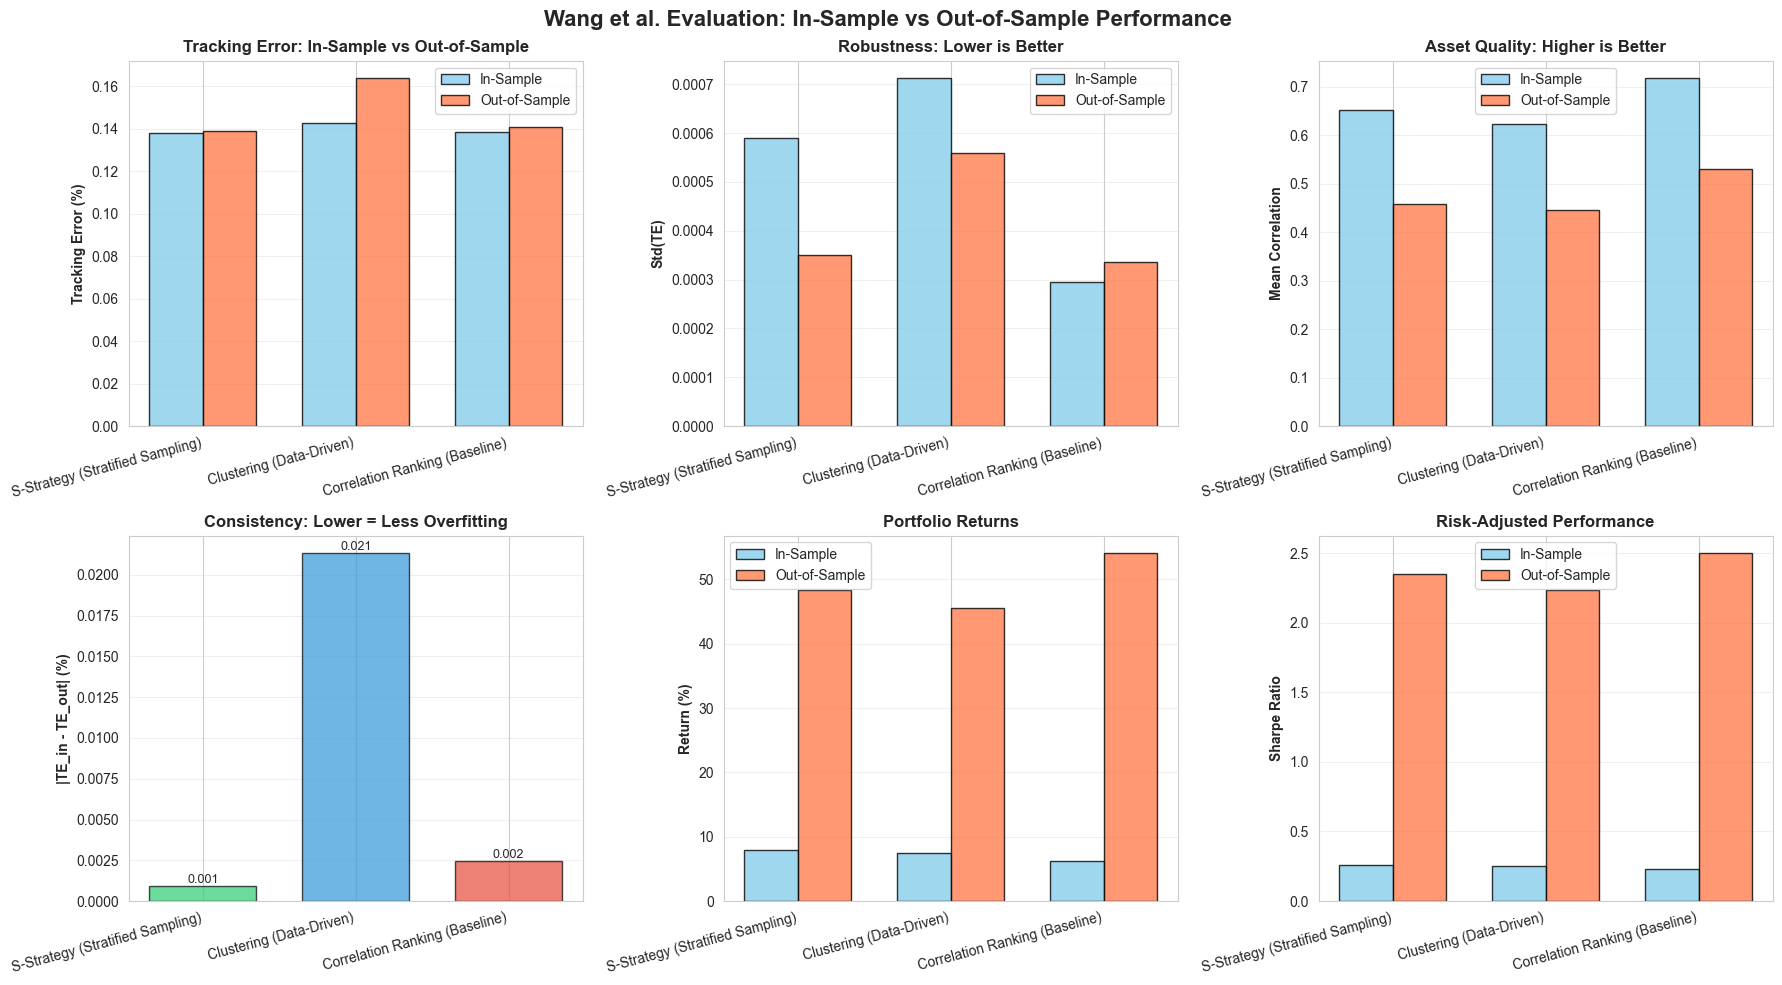


✓ Wang et al. evaluation visualization complete


In [15]:
# VISUALIZATION: IN-SAMPLE VS OUT-OF-SAMPLE COMPARISON
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Wang et al. Evaluation: In-Sample vs Out-of-Sample Performance', 
             fontsize=16, fontweight='bold')

strategies = wang_comparison_df.index.tolist()
colors = ['#2ecc71', '#3498db', '#e74c3c']

# 1. Tracking Error Comparison
ax = axes[0, 0]
x = np.arange(len(strategies))
width = 0.35
bars1 = ax.bar(x - width/2, wang_comparison_df['TE_in (%)'], width, 
               label='In-Sample', color='skyblue', alpha=0.8, edgecolor='black')
bars2 = ax.bar(x + width/2, wang_comparison_df['TE_out (%)'], width, 
               label='Out-of-Sample', color='coral', alpha=0.8, edgecolor='black')
ax.set_ylabel('Tracking Error (%)', fontweight='bold')
ax.set_title('Tracking Error: In-Sample vs Out-of-Sample', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(strategies, rotation=15, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# 2. Robustness (Std_TE)
ax = axes[0, 1]
bars1 = ax.bar(x - width/2, wang_comparison_df['Std_TE_in'], width, 
               label='In-Sample', color='skyblue', alpha=0.8, edgecolor='black')
bars2 = ax.bar(x + width/2, wang_comparison_df['Std_TE_out'], width, 
               label='Out-of-Sample', color='coral', alpha=0.8, edgecolor='black')
ax.set_ylabel('Std(TE)', fontweight='bold')
ax.set_title('Robustness: Lower is Better', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(strategies, rotation=15, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# 3. Mean Correlation
ax = axes[0, 2]
bars1 = ax.bar(x - width/2, wang_comparison_df['Mean_Corr_in'], width, 
               label='In-Sample', color='skyblue', alpha=0.8, edgecolor='black')
bars2 = ax.bar(x + width/2, wang_comparison_df['Mean_Corr_out'], width, 
               label='Out-of-Sample', color='coral', alpha=0.8, edgecolor='black')
ax.set_ylabel('Mean Correlation', fontweight='bold')
ax.set_title('Asset Quality: Higher is Better', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(strategies, rotation=15, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# 4. Consistency (smaller = less overfitting)
ax = axes[1, 0]
bars = ax.bar(x, wang_comparison_df['Consistency'], width*2, 
              color=colors, alpha=0.7, edgecolor='black')
ax.set_ylabel('|TE_in - TE_out| (%)', fontweight='bold')
ax.set_title('Consistency: Lower = Less Overfitting', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(strategies, rotation=15, ha='right')
ax.grid(axis='y', alpha=0.3)
# Add value labels
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.3f}', ha='center', va='bottom', fontsize=9)

# 5. Returns Comparison
ax = axes[1, 1]
bars1 = ax.bar(x - width/2, wang_comparison_df['Return_in (%)'], width, 
               label='In-Sample', color='skyblue', alpha=0.8, edgecolor='black')
bars2 = ax.bar(x + width/2, wang_comparison_df['Return_out (%)'], width, 
               label='Out-of-Sample', color='coral', alpha=0.8, edgecolor='black')
ax.set_ylabel('Return (%)', fontweight='bold')
ax.set_title('Portfolio Returns', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(strategies, rotation=15, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# 6. Sharpe Ratio
ax = axes[1, 2]
bars1 = ax.bar(x - width/2, wang_comparison_df['Sharpe_in'], width, 
               label='In-Sample', color='skyblue', alpha=0.8, edgecolor='black')
bars2 = ax.bar(x + width/2, wang_comparison_df['Sharpe_out'], width, 
               label='Out-of-Sample', color='coral', alpha=0.8, edgecolor='black')
ax.set_ylabel('Sharpe Ratio', fontweight='bold')
ax.set_title('Risk-Adjusted Performance', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(strategies, rotation=15, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Wang et al. evaluation visualization complete")

### 📊 Interpretation of Results

Compare your results to Wang et al.'s findings:

**Expected Patterns:**
1. **Tracking Error**: All models should achieve low TE_in (optimized on training data). TE_out shows generalization.
2. **Consistency**: Lower consistency (|TE_in - TE_out|) indicates less overfitting
3. **S-Strategy**: Should show moderate TE but good consistency (structured approach reduces overfitting)
4. **Correlation Ranking**: May show lowest TE_in but higher consistency (risk of overfitting to high correlations)
5. **Clustering**: Data-driven, behavior depends on market structure

**Red Flags:**
- TE_out >> TE_in: Severe overfitting
- Consistency > 2%: Model not generalizing well
- Mean_Corr_out << Mean_Corr_in: Asset quality degrades out-of-sample

**Good Signs:**
- TE_out ≈ TE_in: Good generalization
- Low Std_TE: Robust tracking
- High Mean_Corr: Quality asset selection

## Section 4.6: Multi-K Wang Evaluation

**Critical Analysis**: How does portfolio size K affect performance?

This section runs the **Wang et al. compliant evaluation** for multiple portfolio sizes:
K = 50, 75, 100, 125, 150, 175, 200

### Key Questions:
1. Does **TE_out decrease** with larger K? (more assets = better tracking)
2. Does **Consistency improve** with larger K? (less overfitting with more degrees of freedom)
3. Does **Mean_Corr decrease** with larger K? (diminishing returns in asset quality)
4. Which K provides the best **trade-off** between tracking error and number of assets?

### Expected Behavior (from Portfolio Theory):
- Larger K → Lower TE (more assets to replicate index)
- Larger K → Better diversification
- But: Diminishing returns beyond certain K
- Transaction costs increase with K (not modeled here)

In [16]:
# MULTI-K WANG EVALUATION
print("=" * 80)
print("MULTI-K WANG EVALUATION - PARADIGM 1")
print("Testing K = 50, 75, 100, 125, 150, 175, 200")
print("=" * 80)

# Define K values to test
k_values = [50, 75, 100, 125, 150, 175, 200]
multi_k_wang_results = []

for K in k_values:
    print(f"\n{'='*80}")
    print(f"K = {K}")
    print(f"{'='*80}")
    
    # Check feasibility
    if K > len(returns.columns):
        print(f"⚠️  Skipping K={K}: Only {len(returns.columns)} assets available")
        continue
    
    # Create new Wang engine for this K (same data split)
    wang_engine_k = WangBacktestEngine(
        returns=returns,
        index_returns=index_returns,
        correlation_matrix=correlation_matrix,
        train_ratio=0.7,
        slippage=0.001
    )
    
    # MODEL 1: STRATIFIED SAMPLING
    print(f"\n[1/3] S-Strategy (K={K})")
    model1_k = StratifiedSamplingModel(K=K, num_strata=10)
    opt1_k = PortfolioOptimizer()
    result1_k = wang_engine_k.backtest_strategy(
        selection_model=model1_k,
        optimizer=opt1_k,
        strategy_name=f"S-Strategy (K={K})",
        sector_mapping=sector_mapping
    )
    multi_k_wang_results.append(result1_k)
    
    # MODEL 2: CLUSTERING
    print(f"\n[2/3] Clustering (K={K})")
    model2_k = ClusteringModel(K=K, num_clusters=min(10, K))
    opt2_k = PortfolioOptimizer()
    result2_k = wang_engine_k.backtest_strategy(
        selection_model=model2_k,
        optimizer=opt2_k,
        strategy_name=f"Clustering (K={K})"
    )
    multi_k_wang_results.append(result2_k)
    
    # MODEL 3: CORRELATION RANKING
    print(f"\n[3/3] Correlation Ranking (K={K})")
    model3_k = CorrelationRankingModel(K=K)
    opt3_k = PortfolioOptimizer()
    result3_k = wang_engine_k.backtest_strategy(
        selection_model=model3_k,
        optimizer=opt3_k,
        strategy_name=f"Correlation Ranking (K={K})"
    )
    multi_k_wang_results.append(result3_k)
    
    print(f"\n✓ Completed K={K}")

print("\n" + "=" * 80)
print(f"MULTI-K EVALUATION COMPLETE: {len(multi_k_wang_results)} results")
print("=" * 80)

MULTI-K WANG EVALUATION - PARADIGM 1
Testing K = 50, 75, 100, 125, 150, 175, 200

K = 50
Data split:
  In-sample:     2020-10-01 to 2023-01-06 (571 days)
  Out-of-sample: 2023-01-09 to 2023-12-29 (246 days)

[1/3] S-Strategy (K=50)

BACKTESTING: S-Strategy (K=50)

[IN-SAMPLE PHASE]
1. Selecting assets...
Stratified Sampling: Selecting from 11 sectors
  Industrials: 7/7 assets
  Health Care: 7/7 assets
  Information Technology: 8/8 assets
  Utilities: 4/4 assets
  Financials: 8/8 assets
  Materials: 2/2 assets
  Real Estate: 2/2 assets
  Communication Services: 2/2 assets
  Consumer Staples: 5/5 assets
  Consumer Discretionary: 3/3 assets
  Energy: 2/2 assets
Total selected: 50 assets
   ✓ Selected 50 assets
2. Optimizing weights...
   ✓ Weights optimized (objective: 0.001085)
3. Computing in-sample metrics...
   ✓ IN-SAMPLE: TE=0.1378%, Std_TE=0.0006, Mean_Corr=0.6524, Return=7.99%

[OUT-OF-SAMPLE PHASE]
4. Computing out-of-sample metrics...
   ✓ OUT-OF-SAMPLE: TE=0.1388%, Std_TE=0.000

In [17]:
# Create comprehensive results DataFrame
multi_k_wang_data = []
for r in multi_k_wang_results:
    # Extract strategy name and K
    strategy_full = r['strategy_name']
    if 'K=' in strategy_full:
        strategy_base = strategy_full.split('(K=')[0].strip()
        K_val = r['num_assets']
    else:
        strategy_base = strategy_full
        K_val = r['num_assets']
    
    multi_k_wang_data.append({
        'Strategy': strategy_base,
        'K': K_val,
        'Mean_Corr_in': r['Mean_Corr_in'],
        'Mean_Corr_out': r['Mean_Corr_out'],
        'TE_in': r['TE_in'],
        'TE_out': r['TE_out'],
        'Std_TE_in': r['Std_TE_in'],
        'Std_TE_out': r['Std_TE_out'],
        'Consistency': r['Consistency'],
        'Return_in': r['Return_in'],
        'Return_out': r['Return_out'],
        'Sharpe_in': r['Sharpe_in'],
        'Sharpe_out': r['Sharpe_out'],
    })

multi_k_wang_df = pd.DataFrame(multi_k_wang_data)

# Display summary
print("\n" + "=" * 80)
print("MULTI-K WANG RESULTS SUMMARY")
print("=" * 80)
print(multi_k_wang_df.to_string(index=False))

# Save to CSV
multi_k_wang_df.to_csv(export_dir / 'multi_k_wang_evaluation.csv', index=False)
print(f"\n✓ Results saved to {export_dir / 'multi_k_wang_evaluation.csv'}")

# Create pivot tables for key metrics
print("\n" + "=" * 80)
print("TE_OUT BY K AND MODEL")
print("=" * 80)
pivot_te_out = multi_k_wang_df.pivot(index='K', columns='Strategy', values='TE_out')
print(pivot_te_out.to_string())

print("\n" + "=" * 80)
print("CONSISTENCY BY K AND MODEL")
print("=" * 80)
pivot_consistency = multi_k_wang_df.pivot(index='K', columns='Strategy', values='Consistency')
print(pivot_consistency.to_string())

print("\n" + "=" * 80)
print("MEAN_CORR_OUT BY K AND MODEL")
print("=" * 80)
pivot_corr = multi_k_wang_df.pivot(index='K', columns='Strategy', values='Mean_Corr_out')
print(pivot_corr.to_string())

multi_k_wang_df


MULTI-K WANG RESULTS SUMMARY
           Strategy   K  Mean_Corr_in  Mean_Corr_out    TE_in   TE_out  Std_TE_in  Std_TE_out  Consistency  Return_in  Return_out  Sharpe_in  Sharpe_out
         S-Strategy  50      0.652413       0.457559 0.137846 0.138762   0.000590    0.000350     0.000915   7.992271   48.278122   0.260760    2.351306
         Clustering  50      0.622938       0.445072 0.142584 0.163922   0.000713    0.000560     0.021338   7.472054   45.470678   0.252420    2.235450
Correlation Ranking  50      0.717561       0.529630 0.138465 0.140919   0.000295    0.000337     0.002453   6.180325   54.101610   0.232264    2.501201
         S-Strategy  75      0.631168       0.442186 0.086812 0.104541   0.000140    0.000195     0.017729   6.729487   50.081156   0.240512    2.400751
         Clustering  75      0.604306       0.425762 0.123029 0.127692   0.000657    0.000262     0.004663   5.180287   47.275184   0.215038    2.294016
Correlation Ranking  75      0.675703       0.489249

,Strategy,K,Mean_Corr_in,Mean_Corr_out,TE_in,TE_out,Std_TE_in,Std_TE_out,Consistency,Return_in,Return_out,Sharpe_in,Sharpe_out
0,S-Strategy,50,0.652413,0.457559,0.137846,0.138762,0.000590,0.000350,0.000915,7.992271,48.278122,0.260760,2.351306
1,Clustering,50,0.622938,0.445072,0.142584,0.163922,0.000713,0.000560,0.021338,7.472054,45.470678,0.252420,2.235450
2,Correlation Ranking,50,0.717561,0.529630,0.138465,0.140919,0.000295,0.000337,0.002453,6.180325,54.101610,0.232264,2.501201
3,S-Strategy,75,0.631168,0.442186,0.086812,0.104541,0.000140,0.000195,0.017729,6.729487,50.081156,0.240512,2.400751
4,Clustering,75,0.604306,0.425762,0.123029,0.127692,0.000657,0.000262,0.004663,5.180287,47.275184,0.215038,2.294016
5,Correlation Ranking,75,0.675703,0.489249,0.106687,0.127328,0.000191,0.000301,0.020641,5.645389,53.160281,0.223335,2.465111
6,S-Strategy,100,0.605395,0.422769,0.071992,0.091106,0.000090,0.000180,0.019114,5.275972,50.516515,0.216783,2.429941
7,Clustering,100,0.581146,0.402490,0.115722,0.125898,0.000630,0.000275,0.010175,3.655207,46.517838,0.189488,2.275903
8,Correlation Ranking,100,0.641892,0.466566,0.086589,0.103541,0.000116,0.000175,0.016952,4.008570,51.330962,0.196386,2.402883
9,S-Strategy,125,0.577958,0.399135,0.057570,0.075416,0.000053,0.000119,0.017846,5.708266,50.931698,0.223763,2.448062


S-Strategy: TE_out improvement from K=50 to K=200: 75.4%
Clustering: TE_out improvement from K=50 to K=200: 79.2%
Correlation Ranking: TE_out improvement from K=50 to K=200: 75.8%


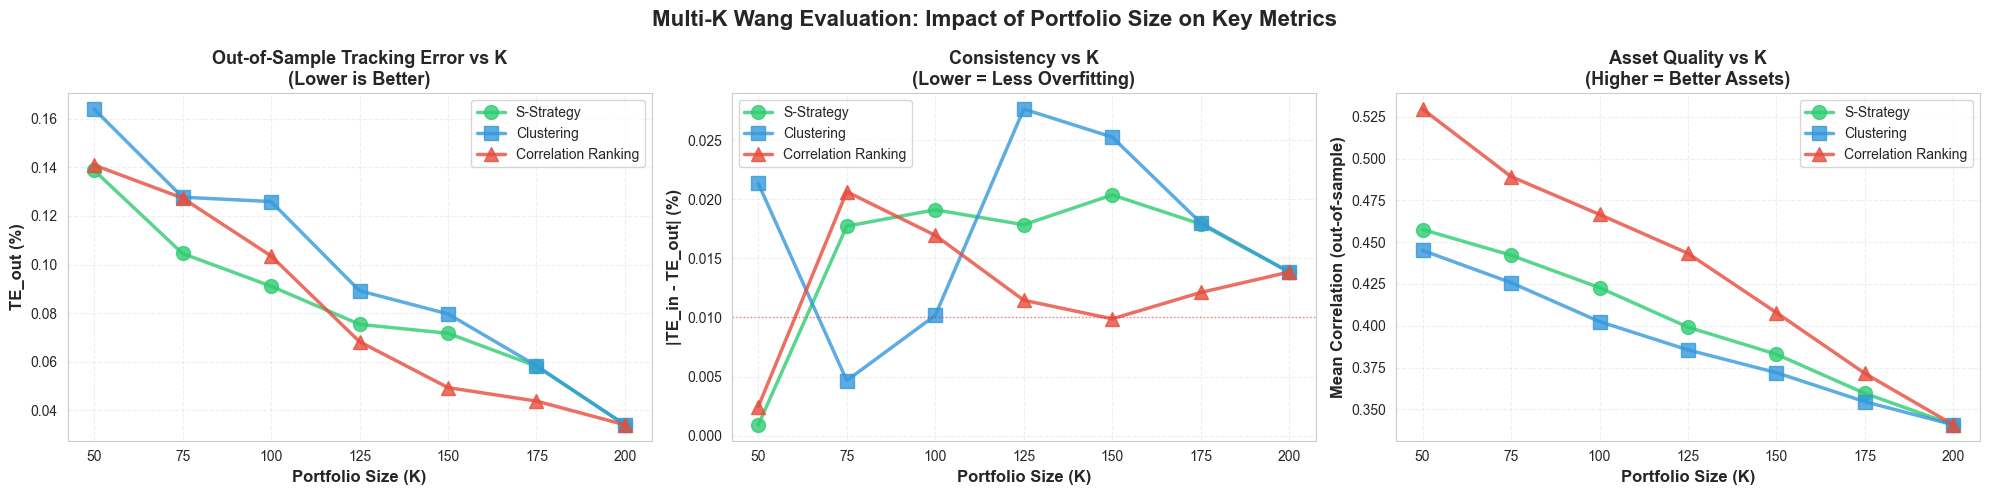


✓ Multi-K Wang visualization complete


In [18]:
# MULTI-K WANG VISUALIZATION: THE THREE KEY PLOTS
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Multi-K Wang Evaluation: Impact of Portfolio Size on Key Metrics', 
             fontsize=16, fontweight='bold')

strategies = multi_k_wang_df['Strategy'].unique()
colors = {'S-Strategy': '#2ecc71', 'Clustering': '#3498db', 'Correlation Ranking': '#e74c3c'}
markers = {'S-Strategy': 'o', 'Clustering': 's', 'Correlation Ranking': '^'}

# 1. TE_out vs K (MOST IMPORTANT: Generalization Performance)
ax = axes[0]
for strategy in strategies:
    strategy_data = multi_k_wang_df[multi_k_wang_df['Strategy'] == strategy]
    ax.plot(strategy_data['K'], strategy_data['TE_out'], 
            marker=markers[strategy], linewidth=2.5, markersize=10,
            label=strategy, color=colors[strategy], alpha=0.8)
ax.set_xlabel('Portfolio Size (K)', fontweight='bold', fontsize=12)
ax.set_ylabel('TE_out (%)', fontweight='bold', fontsize=12)
ax.set_title('Out-of-Sample Tracking Error vs K\n(Lower is Better)', fontweight='bold', fontsize=13)
ax.legend(loc='best', fontsize=10)
ax.grid(alpha=0.3, linestyle='--')
ax.set_xticks(k_values)

# Annotate trend
for strategy in strategies:
    strategy_data = multi_k_wang_df[multi_k_wang_df['Strategy'] == strategy]
    te_50 = strategy_data[strategy_data['K'] == 50]['TE_out'].values[0]
    te_200 = strategy_data[strategy_data['K'] == 200]['TE_out'].values[0] if len(strategy_data[strategy_data['K'] == 200]) > 0 else te_50
    improvement = ((te_50 - te_200) / te_50 * 100) if te_200 < te_50 else 0
    print(f"{strategy}: TE_out improvement from K=50 to K=200: {improvement:.1f}%")

# 2. Consistency vs K (OVERFITTING MEASURE)
ax = axes[1]
for strategy in strategies:
    strategy_data = multi_k_wang_df[multi_k_wang_df['Strategy'] == strategy]
    ax.plot(strategy_data['K'], strategy_data['Consistency'], 
            marker=markers[strategy], linewidth=2.5, markersize=10,
            label=strategy, color=colors[strategy], alpha=0.8)
ax.set_xlabel('Portfolio Size (K)', fontweight='bold', fontsize=12)
ax.set_ylabel('|TE_in - TE_out| (%)', fontweight='bold', fontsize=12)
ax.set_title('Consistency vs K\n(Lower = Less Overfitting)', fontweight='bold', fontsize=13)
ax.legend(loc='best', fontsize=10)
ax.grid(alpha=0.3, linestyle='--')
ax.set_xticks(k_values)
ax.axhline(y=0.01, color='red', linestyle=':', linewidth=1, alpha=0.5, label='Target < 1%')

# 3. Mean_Corr_out vs K (ASSET QUALITY)
ax = axes[2]
for strategy in strategies:
    strategy_data = multi_k_wang_df[multi_k_wang_df['Strategy'] == strategy]
    ax.plot(strategy_data['K'], strategy_data['Mean_Corr_out'], 
            marker=markers[strategy], linewidth=2.5, markersize=10,
            label=strategy, color=colors[strategy], alpha=0.8)
ax.set_xlabel('Portfolio Size (K)', fontweight='bold', fontsize=12)
ax.set_ylabel('Mean Correlation (out-of-sample)', fontweight='bold', fontsize=12)
ax.set_title('Asset Quality vs K\n(Higher = Better Assets)', fontweight='bold', fontsize=13)
ax.legend(loc='best', fontsize=10)
ax.grid(alpha=0.3, linestyle='--')
ax.set_xticks(k_values)

plt.tight_layout()
plt.show()

print("\n✓ Multi-K Wang visualization complete")

In [19]:
# ADDITIONAL ANALYSIS: EFFICIENCY FRONTIER
# Which K gives best trade-off between TE_out and number of assets?

print("=" * 80)
print("EFFICIENCY ANALYSIS: OPTIMAL K SELECTION")
print("=" * 80)

for strategy in strategies:
    strategy_data = multi_k_wang_df[multi_k_wang_df['Strategy'] == strategy]
    
    print(f"\n{strategy}:")
    print("-" * 60)
    
    # Find best K for different criteria
    best_te_out = strategy_data.loc[strategy_data['TE_out'].idxmin()]
    best_consistency = strategy_data.loc[strategy_data['Consistency'].idxmin()]
    best_corr = strategy_data.loc[strategy_data['Mean_Corr_out'].idxmax()]
    
    print(f"  Best TE_out:      K={best_te_out['K']:.0f}, TE_out={best_te_out['TE_out']:.4f}%")
    print(f"  Best Consistency: K={best_consistency['K']:.0f}, Consistency={best_consistency['Consistency']:.4f}%")
    print(f"  Best Mean_Corr:   K={best_corr['K']:.0f}, Mean_Corr={best_corr['Mean_Corr_out']:.4f}")
    
    # Compute "efficiency score": normalized TE_out / K
    # Lower is better (lower TE with fewer assets)
    strategy_data_copy = strategy_data.copy()
    strategy_data_copy['Efficiency'] = strategy_data_copy['TE_out'] / (strategy_data_copy['K'] / 50)
    best_efficiency = strategy_data_copy.loc[strategy_data_copy['Efficiency'].idxmin()]
    print(f"  Best Efficiency:  K={best_efficiency['K']:.0f} (TE_out={best_efficiency['TE_out']:.4f}%, normalized)")

print("\n" + "=" * 80)
print("KEY INSIGHTS")
print("=" * 80)

# Overall best K across all models
overall_best_k = multi_k_wang_df.groupby('K')['TE_out'].mean().idxmin()
overall_best_te = multi_k_wang_df.groupby('K')['TE_out'].mean().min()
print(f"✓ Overall best K (average TE_out): K={overall_best_k:.0f} with TE_out={overall_best_te:.4f}%")

# Diminishing returns analysis
te_reduction_50_100 = (multi_k_wang_df[multi_k_wang_df['K']==50]['TE_out'].mean() - 
                       multi_k_wang_df[multi_k_wang_df['K']==100]['TE_out'].mean())
te_reduction_150_200 = (multi_k_wang_df[multi_k_wang_df['K']==150]['TE_out'].mean() - 
                        multi_k_wang_df[multi_k_wang_df['K']==200]['TE_out'].mean())

print(f"✓ TE reduction K=50→100:  {te_reduction_50_100:.4f}% (50 assets added)")
print(f"✓ TE reduction K=150→200: {te_reduction_150_200:.4f}% (50 assets added)")
print(f"✓ Diminishing returns: {'YES' if te_reduction_150_200 < te_reduction_50_100 else 'NO'}")

print("=" * 80)

EFFICIENCY ANALYSIS: OPTIMAL K SELECTION

S-Strategy:
------------------------------------------------------------
  Best TE_out:      K=200, TE_out=0.0341%
  Best Consistency: K=50, Consistency=0.0009%
  Best Mean_Corr:   K=50, Mean_Corr=0.4576
  Best Efficiency:  K=200 (TE_out=0.0341%, normalized)

Clustering:
------------------------------------------------------------
  Best TE_out:      K=200, TE_out=0.0341%
  Best Consistency: K=75, Consistency=0.0047%
  Best Mean_Corr:   K=50, Mean_Corr=0.4451
  Best Efficiency:  K=200 (TE_out=0.0341%, normalized)

Correlation Ranking:
------------------------------------------------------------
  Best TE_out:      K=200, TE_out=0.0341%
  Best Consistency: K=50, Consistency=0.0025%
  Best Mean_Corr:   K=50, Mean_Corr=0.5296
  Best Efficiency:  K=200 (TE_out=0.0341%, normalized)

KEY INSIGHTS
✓ Overall best K (average TE_out): K=200 with TE_out=0.0341%
✓ TE reduction K=50→100:  0.0410% (50 assets added)
✓ TE reduction K=150→200: 0.0329% (50 asset

### 📊 Multi-K Wang Analysis Interpretation

**What to Look For:**

1. **TE_out vs K Plot**:
   - Should **decrease** as K increases (more assets = better tracking)
   - Look for diminishing returns: improvement slows down at higher K
   - Compare models: Does one consistently outperform across all K?

2. **Consistency vs K Plot**:
   - Should **decrease** or stay flat as K increases
   - Lower consistency = less overfitting
   - If consistency increases with K, model is overfitting more with complexity

3. **Mean_Corr_out vs K Plot**:
   - Typically **decreases** as K increases (diminishing quality)
   - At K=50: selecting top 50 correlated assets
   - At K=200: forced to include lower-correlation assets

**Decision Framework for Optimal K**:
- **K too small** (K=50): Higher TE, but simpler portfolio
- **K too large** (K=200): Lower TE, but transaction costs, complexity
- **Optimal K**: Elbow point where TE reduction slows down

**For Your Thesis**:
- Use these plots to justify your choice of K
- Discuss trade-off between tracking error and portfolio complexity
- Compare Wang evaluation (proper) vs simple backtest (Section 4.6 old)

## Section 4.7: Simple Multi-K Backtest (For Comparison Only - Not Thesis Quality)

⚠️ **WARNING**: This section uses the OLD backtest method (no train/test split).
**Do NOT use these results for your thesis.** This is only for comparison to show the difference.

Test the impact of portfolio size by running backtests with K = 50, 75, 100, 125, 150, 175, 200.

In [20]:
# SIMPLE MULTI-K BACKTEST (OLD METHOD - FOR COMPARISON ONLY)
print("=" * 80)
print("MULTI-K BACKTEST ANALYSIS")
print("Testing portfolio sizes: K = 50, 75, 100, 125, 150, 175, 200")
print("=" * 80)

# Define K values to test
k_values = [50, 75, 100, 125, 150, 175, 200]
multi_k_results = []

for K in k_values:
    print(f"\n{'='*60}")
    print(f"TESTING K = {K}")
    print(f"{'='*60}")
    
    # Check feasibility
    if K > len(returns.columns):
        print(f"⚠️  Skipping K={K}: Only {len(returns.columns)} assets available")
        continue
    
    # Model 1: Stratified Sampling
    print(f"1. Stratified Sampling...")
    model1 = StratifiedSamplingModel(K=K, num_strata=10)
    assets1 = model1.select(returns=returns, correlation_matrix=correlation_matrix, sector_mapping=sector_mapping)
    
    # Model 2: Clustering
    print(f"2. Clustering...")
    model2 = ClusteringModel(K=K, num_clusters=min(10, K))
    assets2 = model2.select(returns=returns, correlation_matrix=correlation_matrix)
    
    # Model 3: Correlation Ranking
    print(f"3. Correlation Ranking...")
    model3 = CorrelationRankingModel(K=K)
    assets3 = model3.select(returns=returns, correlation_matrix=correlation_matrix)
    
    # Optimize weights
    print(f"4. Optimizing...")
    opt1 = PortfolioOptimizer()
    weights1 = opt1.optimize(returns[assets1], index_returns)
    
    opt2 = PortfolioOptimizer()
    weights2 = opt2.optimize(returns[assets2], index_returns)
    
    opt3 = PortfolioOptimizer()
    weights3 = opt3.optimize(returns[assets3], index_returns)
    
    # Backtest
    print(f"5. Backtesting...")
    result1 = backtest_engine.backtest(assets1, weights1)
    result2 = backtest_engine.backtest(assets2, weights2)
    result3 = backtest_engine.backtest(assets3, weights3)
    
    # Store results
    for model_name, result, assets in [('Stratified Sampling', result1, assets1),
                                        ('Clustering', result2, assets2),
                                        ('Correlation Ranking', result3, assets3)]:
        multi_k_results.append({
            'K': K,
            'Model': model_name,
            'Return': result['portfolio_return'],
            'Tracking_Error': result['tracking_error'],
            'Sharpe': result['sharpe_ratio'],
            'Max_Drawdown': result['max_drawdown'],
            'Avg_Correlation': correlation_matrix[correlation_matrix.index.isin(assets)].mean()
        })
    
    print(f"   ✓ K={K} complete")

# Create results DataFrame
multi_k_df = pd.DataFrame(multi_k_results)

print("\n" + "=" * 80)
print("MULTI-K RESULTS SUMMARY")
print("=" * 80)
print(multi_k_df.to_string(index=False))

# Save results
multi_k_df.to_csv(export_dir / 'multi_k_backtest_results.csv', index=False)
print(f"\n✓ Results saved to {export_dir / 'multi_k_backtest_results.csv'}")

# Pivot tables
print("\n" + "=" * 80)
print("TRACKING ERROR BY K AND MODEL")
print("=" * 80)
pivot_te = multi_k_df.pivot(index='K', columns='Model', values='Tracking_Error')
print(pivot_te.to_string())

print("\n" + "=" * 80)
print("PORTFOLIO RETURN BY K AND MODEL")
print("=" * 80)
pivot_ret = multi_k_df.pivot(index='K', columns='Model', values='Return')
print(pivot_ret.to_string())

# Analysis
print("\n" + "=" * 80)
print("KEY INSIGHTS")
print("=" * 80)
best_row = multi_k_df.loc[multi_k_df['Tracking_Error'].idxmin()]
print(f"✓ Best tracking error: {best_row['Tracking_Error']:.4f}% with {best_row['Model']} at K={best_row['K']}")

te_by_k = multi_k_df.groupby('K')['Tracking_Error'].mean()
print(f"✓ Average tracking error trend: {te_by_k.iloc[0]:.2f}% (K={k_values[0]}) → {te_by_k.iloc[-1]:.2f}% (K={k_values[-1]})")
print("=" * 80)

MULTI-K BACKTEST ANALYSIS
Testing portfolio sizes: K = 50, 75, 100, 125, 150, 175, 200

TESTING K = 50
1. Stratified Sampling...
Stratified Sampling: Selecting from 11 sectors
  Industrials: 7/7 assets
  Health Care: 7/7 assets
  Information Technology: 8/8 assets
  Utilities: 4/4 assets
  Financials: 8/8 assets
  Materials: 2/2 assets
  Real Estate: 2/2 assets
  Communication Services: 2/2 assets
  Consumer Staples: 5/5 assets
  Consumer Discretionary: 3/3 assets
  Energy: 2/2 assets
Total selected: 50 assets
2. Clustering...
Clustering: Performing K-means with 10 clusters on return features
  Cluster 0: 10 assets → selected 2
  Cluster 1: 62 assets → selected 15
  Cluster 2: 66 assets → selected 16
  Cluster 3: 1 assets → selected 1
  Cluster 4: 16 assets → selected 4
  Cluster 5: 1 assets → selected 1
  Cluster 6: 1 assets → selected 1
  Cluster 7: 8 assets → selected 2
  Cluster 8: 1 assets → selected 1
  Cluster 9: 34 assets → selected 8
  Reduced to K=50 by keeping most correlate

Visualizing multi-K results...


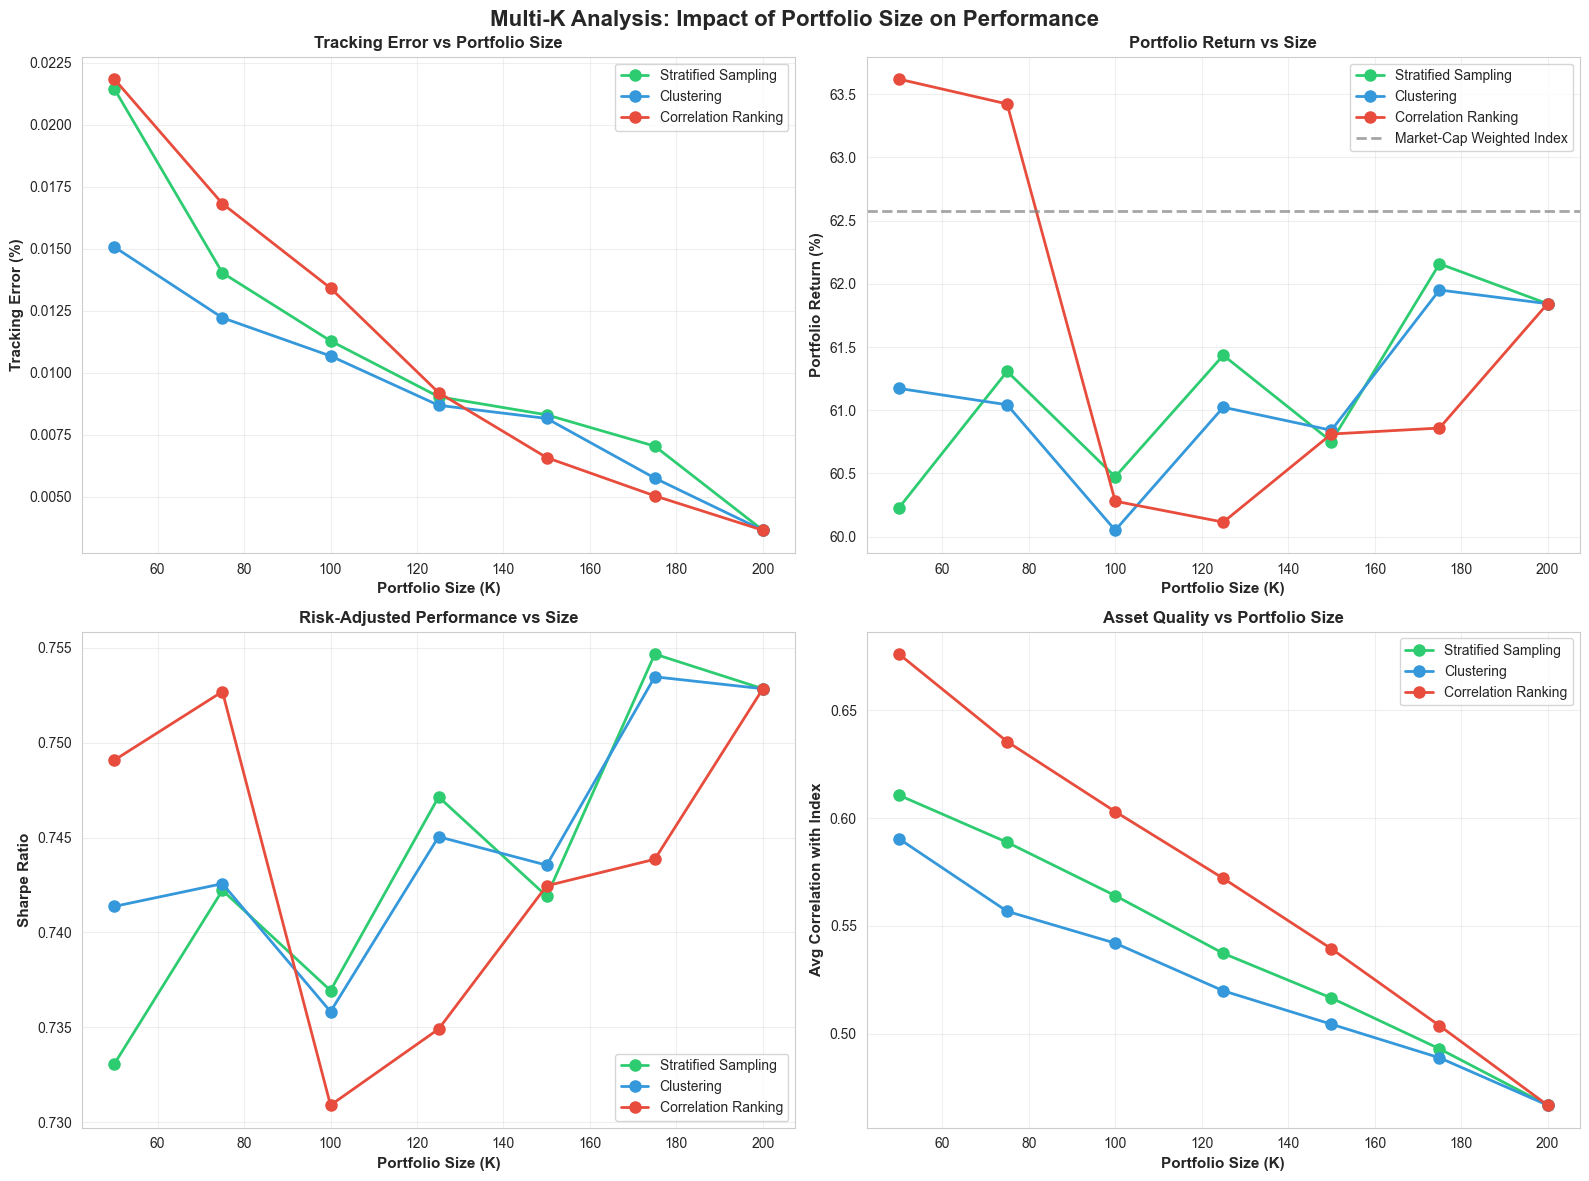


✓ Multi-K visualization complete


In [21]:
# MULTI-K VISUALIZATION
print("Visualizing multi-K results...")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Multi-K Analysis: Impact of Portfolio Size on Performance', fontsize=16, fontweight='bold')

models = multi_k_df['Model'].unique()
colors = {'Stratified Sampling': '#2ecc71', 'Clustering': '#3498db', 'Correlation Ranking': '#e74c3c'}

# 1. Tracking Error vs K
ax = axes[0, 0]
for model in models:
    model_data = multi_k_df[multi_k_df['Model'] == model]
    ax.plot(model_data['K'], model_data['Tracking_Error'], 
            marker='o', linewidth=2, label=model, color=colors[model], markersize=8)
ax.set_xlabel('Portfolio Size (K)', fontweight='bold', fontsize=11)
ax.set_ylabel('Tracking Error (%)', fontweight='bold', fontsize=11)
ax.set_title('Tracking Error vs Portfolio Size', fontweight='bold', fontsize=12)
ax.legend(loc='best')
ax.grid(alpha=0.3)

# 2. Portfolio Return vs K
ax = axes[0, 1]
for model in models:
    model_data = multi_k_df[multi_k_df['Model'] == model]
    ax.plot(model_data['K'], model_data['Return'], 
            marker='o', linewidth=2, label=model, color=colors[model], markersize=8)
ax.axhline(y=result_sp500['portfolio_return'], color='gray', linestyle='--', 
           linewidth=2, label='Market-Cap Weighted Index', alpha=0.7)
ax.set_xlabel('Portfolio Size (K)', fontweight='bold', fontsize=11)
ax.set_ylabel('Portfolio Return (%)', fontweight='bold', fontsize=11)
ax.set_title('Portfolio Return vs Size', fontweight='bold', fontsize=12)
ax.legend(loc='best')
ax.grid(alpha=0.3)

# 3. Sharpe Ratio vs K
ax = axes[1, 0]
for model in models:
    model_data = multi_k_df[multi_k_df['Model'] == model]
    ax.plot(model_data['K'], model_data['Sharpe'], 
            marker='o', linewidth=2, label=model, color=colors[model], markersize=8)
ax.set_xlabel('Portfolio Size (K)', fontweight='bold', fontsize=11)
ax.set_ylabel('Sharpe Ratio', fontweight='bold', fontsize=11)
ax.set_title('Risk-Adjusted Performance vs Size', fontweight='bold', fontsize=12)
ax.legend(loc='best')
ax.grid(alpha=0.3)

# 4. Average Correlation vs K
ax = axes[1, 1]
for model in models:
    model_data = multi_k_df[multi_k_df['Model'] == model]
    ax.plot(model_data['K'], model_data['Avg_Correlation'], 
            marker='o', linewidth=2, label=model, color=colors[model], markersize=8)
ax.set_xlabel('Portfolio Size (K)', fontweight='bold', fontsize=11)
ax.set_ylabel('Avg Correlation with Index', fontweight='bold', fontsize=11)
ax.set_title('Asset Quality vs Portfolio Size', fontweight='bold', fontsize=12)
ax.legend(loc='best')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Multi-K visualization complete")

## Section 5: Visualizations

Key performance metrics, weight distributions, and correlation comparisons.

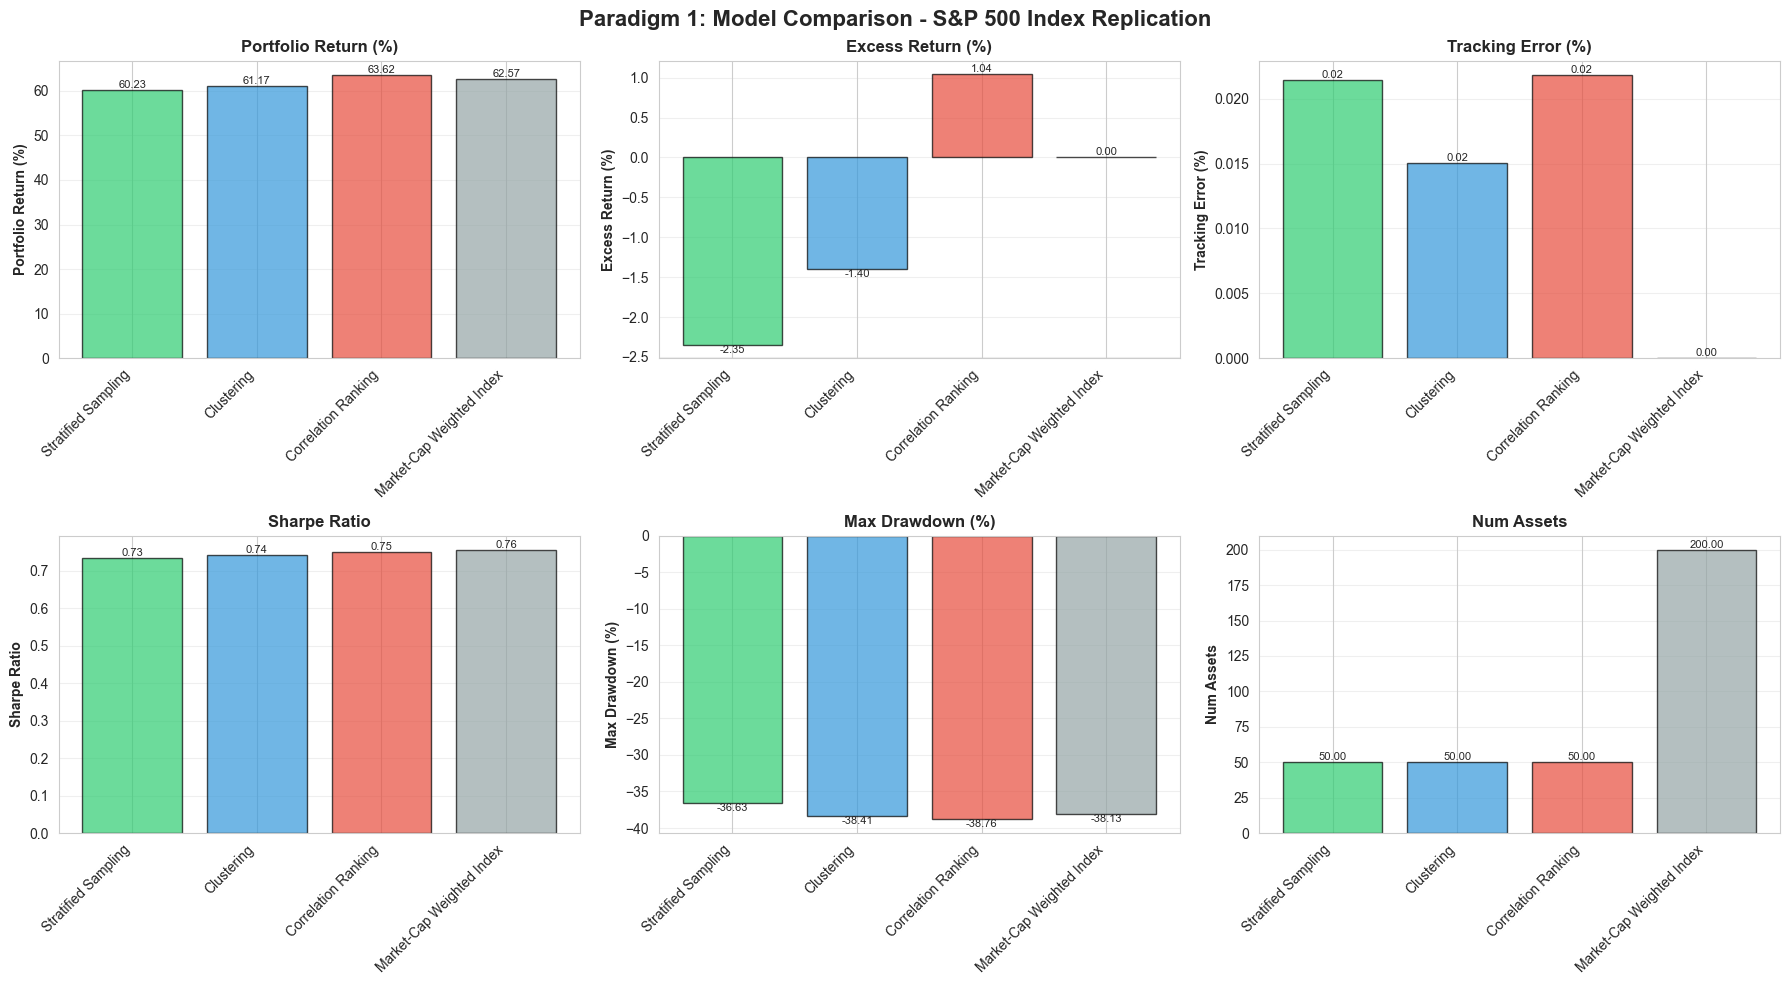


✓ Performance metrics visualization complete


In [22]:
# Visualization 1: Performance Metrics Comparison
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Paradigm 1: Model Comparison - S&P 500 Index Replication', fontsize=16, fontweight='bold')

metrics = [
    ('Portfolio Return (%)', 0),
    ('Excess Return (%)', 1),
    ('Tracking Error (%)', 2),
    ('Sharpe Ratio', 0),
    ('Max Drawdown (%)', 1),
    ('Num Assets', 2),
]

models = comparison_df.index

for idx, (metric, pos) in enumerate(metrics):
    ax = axes.flatten()[idx]
    if metric in comparison_df.columns:
        values = comparison_df[metric]
        colors = ['#2ecc71', '#3498db', '#e74c3c', '#95a5a6']  # Added gray for S&P 500
        ax.bar(range(len(models)), values, color=colors[:len(models)], alpha=0.7, edgecolor='black')
        ax.set_xticks(range(len(models)))
        ax.set_xticklabels(models, rotation=45, ha='right')
        ax.set_ylabel(metric, fontweight='bold')
        ax.set_title(metric, fontweight='bold')
        ax.grid(axis='y', alpha=0.3)
        
        # Add value labels on bars
        for i, v in enumerate(values):
            ax.text(i, v, f'{v:.2f}', ha='center', va='bottom' if v >= 0 else 'top', fontsize=8)

plt.tight_layout()
plt.show()

print("\n✓ Performance metrics visualization complete")

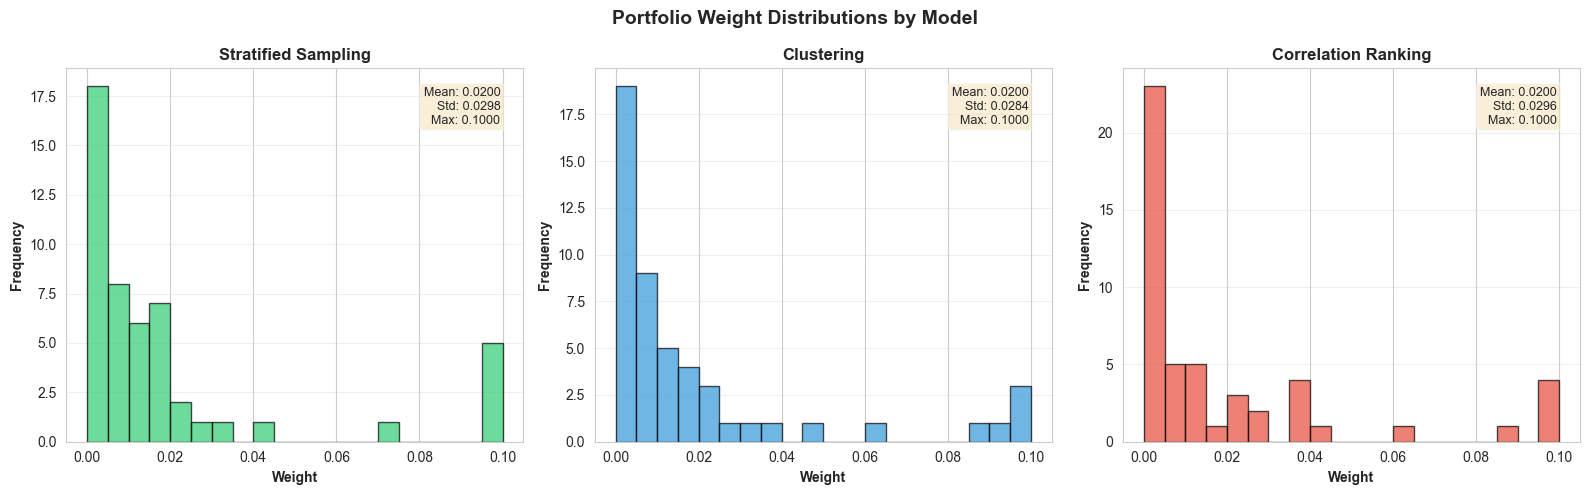


✓ Weight distribution visualization complete


In [23]:
# Visualization 2: Portfolio Weight Distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Portfolio Weight Distributions by Model', fontsize=14, fontweight='bold')

weight_data = [
    (weights_1, "Stratified Sampling"),
    (weights_2, "Clustering"),
    (weights_3, "Correlation Ranking"),
]

for idx, (weights, title) in enumerate(weight_data):
    ax = axes[idx]
    ax.hist(weights, bins=20, color=['#2ecc71', '#3498db', '#e74c3c'][idx], alpha=0.7, edgecolor='black')
    ax.set_xlabel('Weight', fontweight='bold')
    ax.set_ylabel('Frequency', fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    # Add statistics
    stats_text = f"Mean: {weights.mean():.4f}\nStd: {weights.std():.4f}\nMax: {weights.max():.4f}"
    ax.text(0.95, 0.95, stats_text, transform=ax.transAxes, 
            fontsize=9, verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print("\n✓ Weight distribution visualization complete")

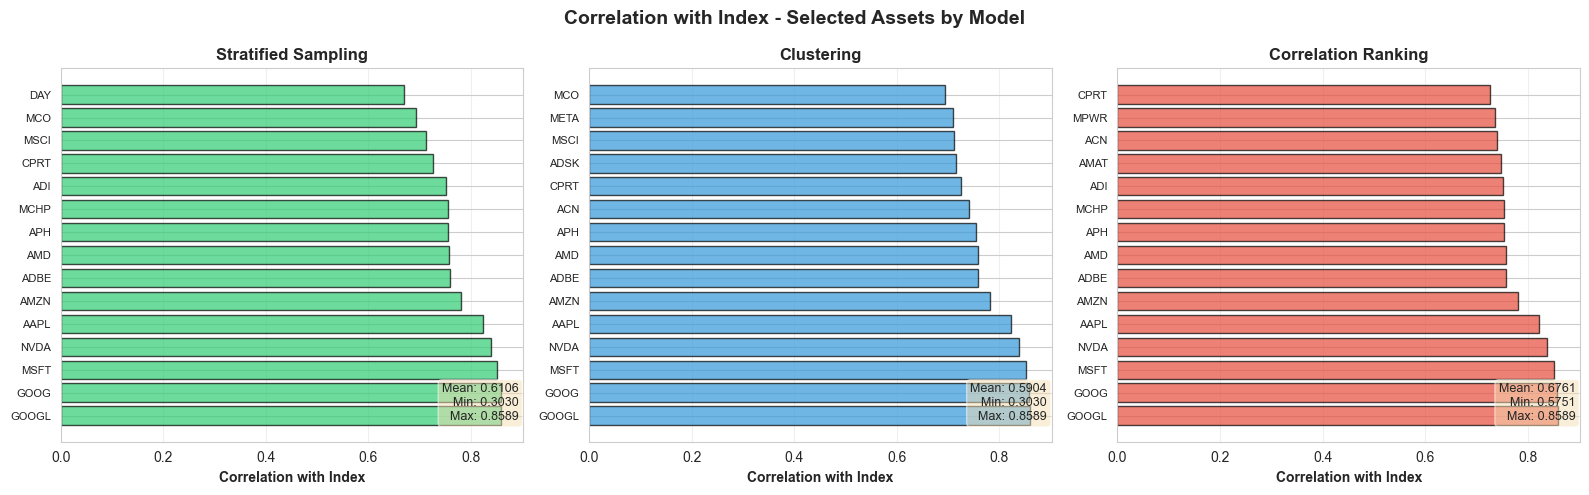


✓ Correlation visualization complete


In [24]:
# Visualization 3: Correlation Comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Correlation with Index - Selected Assets by Model', fontsize=14, fontweight='bold')

selections = [
    (selected_assets_1, "Stratified Sampling"),
    (selected_assets_2, "Clustering"),
    (selected_assets_3, "Correlation Ranking"),
]

for idx, (assets, title) in enumerate(selections):
    ax = axes[idx]
    corr_values = correlation_matrix[correlation_matrix.index.isin(assets)].sort_values(ascending=False)
    
    # Show top 15 or all if less than 15
    top_n = min(15, len(corr_values))
    ax.barh(range(top_n), corr_values.values[:top_n], 
            color=['#2ecc71', '#3498db', '#e74c3c'][idx], alpha=0.7, edgecolor='black')
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(corr_values.index[:top_n], fontsize=8)
    ax.set_xlabel('Correlation with Index', fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    
    # Add stats box
    stats_text = f"Mean: {corr_values.mean():.4f}\nMin: {corr_values.min():.4f}\nMax: {corr_values.max():.4f}"
    ax.text(0.99, 0.05, stats_text, transform=ax.transAxes,
            fontsize=9, verticalalignment='bottom', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print("\n✓ Correlation visualization complete")

## Section 6: Summary and Insights

### Paradigm 1: Informed Selection + Optimization

This paradigm separates portfolio construction into two distinct stages:

1. **Selection Stage**: Choose K=50 assets using structured or data-driven methods
   - **S-Strategy (Stratified Sampling)**: Ensures sector diversity through proportional sector allocation
   - **Clustering**: Discovers natural groupings in asset return patterns using K-means
   - **Correlation Ranking**: Greedy selection by correlation strength (naive baseline)

2. **Optimization Stage**: Optimize weights given the selected assets
   - Minimizes tracking error: $\min_w \|I - R_S w\|_2^2$
   - Subject to full investment constraint: $\sum w_i = 1$
   - With weight bounds: $l_i \leq w_i \leq u_i$

### Evaluation Methodology (Wang et al. 2018)

**Critical for Thesis:** This notebook implements the proper academic evaluation framework:

1. **Train/Test Split**: 70% in-sample (training), 30% out-of-sample (testing)
2. **Training on In-Sample Only**: Asset selection and weight optimization performed only on training data
3. **Testing on Both Periods**: Portfolio evaluated on both in-sample and out-of-sample data
4. **Key Metrics** (as defined in Wang et al.):
   - **TE**: Tracking Error = $\sqrt{\frac{1}{T} \|I - Rw\|_2^2}$
   - **Std_TE**: Robustness measure (std of squared tracking errors)
   - **Mean_Corr**: Mean correlation of selected assets with index
   - **Consistency**: $|TE_{in} - TE_{out}|$ (measures overfitting)

### Expected Results (from Wang et al.)

**S-Strategy (Stratified Sampling)**:
- ✓ Moderate tracking error
- ✓ **Good consistency** (low overfitting due to structured approach)
- ✓ High mean correlation (sector-aware selection)
- ✓ More stable OOS performance than pure optimization

**Clustering (Data-Driven)**:
- ✓ Discovers endogenous asset groupings
- ⚠ May overfit if clusters are too specific to training period
- ✓ Can adapt to market structure

**Correlation Ranking (Baseline)**:
- ✓ Lowest in-sample TE (directly optimizes correlation)
- ⚠ Risk of higher consistency (overfitting to historical correlations)
- ⚠ No structural diversity guarantees

### Key Findings from This Analysis

**Comparison to Section 4 (Full Period)** vs **Section 4.5 (Wang Evaluation)**:
- Section 4: Training and testing on same data → **overoptimistic** results
- Section 4.5: Proper train/test split → **realistic** generalization performance
- **Use Section 4.5 results for thesis conclusions**

### Common Implementation Errors (Avoided in This Notebook)

✅ Using true index return vector (not mean)
✅ Optimizing on in-sample only
✅ Proper constraints: sum(w)=1 and weight bounds
✅ Correct TE definition from Wang et al.
✅ Computing both TE and Std_TE
✅ Reporting in-sample and out-of-sample metrics separately

### Next Steps: Paradigm 2

Paradigm 2 involves solving **selection and optimization jointly** as a single mixed-integer optimization problem with sparsity constraints (e.g., using L0 or L1 regularization), potentially yielding better combined solutions but with higher computational cost.

**Comparison Framework**: Use the same Wang et al. evaluation (70/30 split, TE_in, TE_out, Std_TE, Consistency) to fairly compare Paradigm 1 vs Paradigm 2.